# $$IBM - Data- Analyst -Capstone- Project$$ 

# Data Collection

### install the required libraries

In [1]:
!pip install pandas
!pip install numpay
!pip install matplotlib
!pip install seaborn

### Import the required libraries

In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Datasat

In [3]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"

#load into a dataframe
df = pd.read_csv(file_path)

In [4]:
# Show Datasat
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65457 entries, 0 to 65456
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [6]:
# Numbers of rows and columns of data in the dataset.
total_rows= df.shape[0]
total_cols= df.shape[1]
df_shape = df.shape

print(f"DataFrame shape : {df_shape}")
print(f"Total Number of Rows : {total_rows}")
print(f"Total Number of Columns : {total_cols}")

DataFrame shape : (65457, 114)
Total Number of Rows : 65457
Total Number of Columns : 114


In [7]:
# Print the datatype of all columns.
df.dtypes

ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

### 02 Data Wrangling 

Remove Duplicates

In [8]:
## Identifying Duplicate Rows
duplicate_counts = df.duplicated().sum()
duplicate_counts

20

In [9]:
# Remove Duplicates
df_cleaned = df.drop_duplicates(keep="first")

## Handling Duplicates

Identify and Handle Missing Values

In [10]:
# Identify missing values for all columns in the dataset
missing_value = df_cleaned.isna().sum()
print(f"Missing values per column: \n{missing_value}")

Missing values per column: 
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64


Visualize missing values using a heatmap (Using seaborn library).

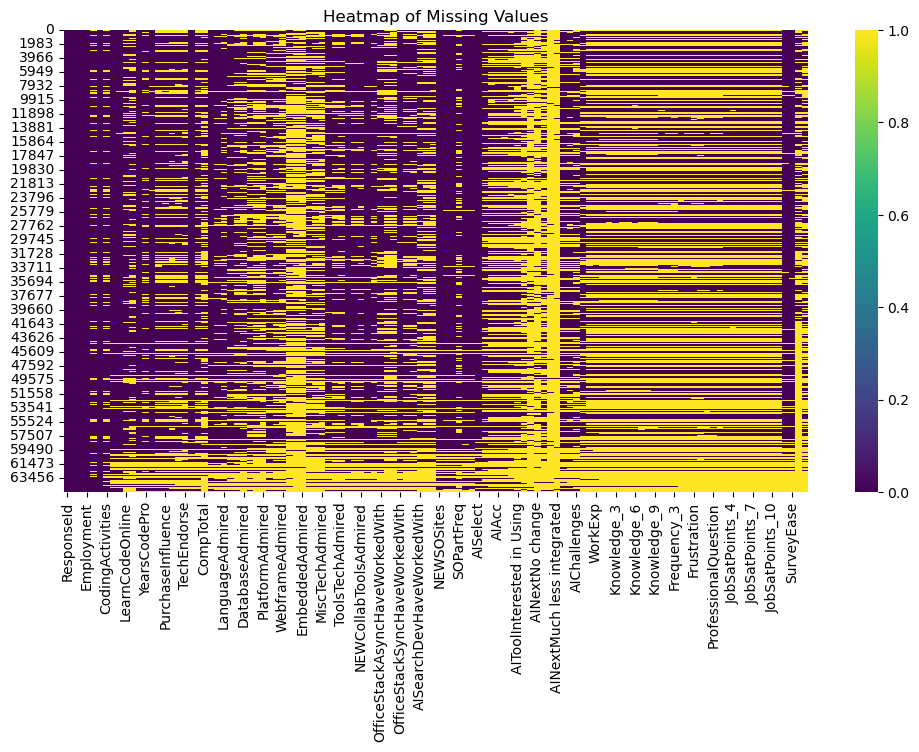

In [11]:
# Visualize missing values using a heatmap
plt.figure(figsize=(12,6))

sns.heatmap(df_cleaned.isnull(),cbar=True, cmap="viridis")
plt.title("Heatmap of Missing Values")
plt.show()

Identify the most frequent (majority) value in the RemoteWork column.

In [12]:
df_cleaned["RemoteWork"].unique()

array(['Remote', nan, 'In-person', 'Hybrid (some remote, some in-person)'],
      dtype=object)

In [13]:
most_frequent_remote = df_cleaned["RemoteWork"].mode()[0]
df_cleaned.loc[:, "RemoteWork"] = df_cleaned["RemoteWork"].fillna(most_frequent_remote)

Identify the most frequent (majority) value in a specific column (e.g., Employment).

In [14]:
most_frequent_emp = df_cleaned["Employment"].mode()[0]
df_cleaned.loc[:,"Employment"] = df_cleaned["Employment"].fillna(most_frequent_emp)

Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.

In [15]:
most_frequent_edl = df_cleaned["EdLevel"].mode()[0]
df_cleaned.loc[:, "EdLevel"] = df_cleaned["EdLevel"].fillna(most_frequent_edl)

Identify missing values in CodingActivities.

In [16]:
df_cleaned.loc[:,"CodingActivities"] = df["CodingActivities"].ffill()

In [17]:
df_cleaned["CodingActivities"].isna().sum()

0

In [18]:
df_cleaned.loc[:,"ConvertedCompYearly"] = pd.to_numeric(df_cleaned["ConvertedCompYearly"], errors="coerce")

In [19]:
# Ensure numeric values
df_cleaned.loc[:,"ConvertedCompYearly"] = df_cleaned.dropna(subset=["ConvertedCompYearly"])

In [20]:
df_cleaned["ConvertedCompYearly"].isna().sum()

42002

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.

### Explore the Dataset

create a detail summary table 

In [21]:
# create a detail summary table 
summary_df = pd.DataFrame({
    "Data Type": df_cleaned.dtypes,
    "Non-Null Count": df_cleaned.count(),
    "Missing Values": df_cleaned.isna().sum(),
    "Missing %": (df_cleaned.isna().sum() / len(df_cleaned)) * 100,
    "Unique Values": df_cleaned.nunique()
})

summary_df = summary_df.reset_index().rename(columns={"index": "Column Name"})

summary_df

,Column Name,Data Type,Non-Null Count,Missing Values,Missing %,Unique Values
0,ResponseId,int64,65437,0,0.000000,65437
1,MainBranch,object,65437,0,0.000000,5
2,Age,object,65437,0,0.000000,8
3,Employment,object,65437,0,0.000000,110
4,RemoteWork,object,65437,0,0.000000,3
...,...,...,...,...,...,...
109,JobSatPoints_11,float64,29445,35992,55.002522,79
110,SurveyLength,object,56182,9255,14.143375,3
111,SurveyEase,object,56238,9199,14.057796,3
112,ConvertedCompYearly,float64,23435,42002,64.186928,6113


Generate basic statistics for numerical columns

In [22]:
df_cleaned.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### Identifying and Removing Inconsistencies

Identify inconsistent or irrelevant entries in specific columns (e.g., Country).

In [23]:
df_cleaned["Country"].value_counts(dropna=False).head()

Country
United States of America                                11095
NaN                                                      6507
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Name: count, dtype: int64

 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format

In [24]:
df_cleaned.loc[:,"Country"] = df["Country"].str.strip().str.title()
df_cleaned["Country"].value_counts().head()

Country
United States Of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom Of Great Britain And Northern Ireland     3224
Ukraine                                                  2672
Name: count, dtype: int64

In [25]:
df_cleaned.loc[:,"EdLevel"] = df_cleaned["EdLevel"].str.strip().str.title()
df_cleaned["EdLevel"].unique()

array(['Primary/Elementary School',
       'Bachelor’S Degree (B.A., B.S., B.Eng., Etc.)',
       'Master’S Degree (M.A., M.S., M.Eng., Mba, Etc.)',
       'Some College/University Study Without Earning A Degree',
       'Secondary School (E.G. American High School, German Realschule Or Gymnasium, Etc.)',
       'Professional Degree (Jd, Md, Ph.D, Ed.D, Etc.)',
       'Associate Degree (A.A., A.S., Etc.)', 'Something Else'],
      dtype=object)

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.

**Encode the Employment column using one-hot encoding.**

In [26]:
# One-hot encode the Employment column
employment_dummies = pd.get_dummies(df_cleaned["Employment"],prefix="Employment", dummy_na=True)

In [27]:
# save the employment_dummies datasat 
employment_dummies.to_csv("employment_dummies.csv", index=False)

In [28]:
employment_dummies.head()

,"Employment_Employed, full-time","Employment_Employed, full-time;Employed, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Retired","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time",...,"Employment_Student, full-time;Not employed, but looking for work;Retired","Employment_Student, full-time;Not employed, but looking for work;Student, part-time","Employment_Student, full-time;Retired","Employment_Student, full-time;Student, part-time","Employment_Student, full-time;Student, part-time;Employed, part-time","Employment_Student, full-time;Student, part-time;Retired","Employment_Student, part-time","Employment_Student, part-time;Employed, part-time","Employment_Student, part-time;Retired",Employment_nan
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### Normalizing Compensation Data

 Identify compensation-related columns, such as ConvertedCompYearly

In [29]:
df_cleaned["ConvertedCompYearly"].unique()

array([    nan,   7322.,  30074., ...,  15637.,   9711., 116844.])

In [30]:
comp_cols = [
    col for col in df_cleaned.columns
    if any (word in col.lower() for word in ["comp", "salary", "income", "pay"])]

comp_cols    

['CompTotal', 'AIComplex', 'ConvertedCompYearly']

**Normalize ConvertedCompYearly using Min-Max Scaling.**

In [44]:
df_cleaned.loc[:,"ConvertedCompYearly_MinMax"] = (
    df_cleaned["ConvertedCompYearly"] - df_cleaned["ConvertedCompYearly"].min()
) / (
    df_cleaned["ConvertedCompYearly"].max() - df_cleaned["ConvertedCompYearly"].min()
)

In [32]:
df_cleaned["ConvertedCompYearly_MinMax"].describe()

count    23435.000000
mean         0.005300
std          0.011488
min          0.000000
25%          0.002012
50%          0.003998
75%          0.006642
max          1.000000
Name: ConvertedCompYearly_MinMax, dtype: float64

In [33]:
df_cleaned["ConvertedCompYearly"].count()

23435

**Apply Z-score Normalization to ConvertedCompYearly**

In [45]:
df_cleaned.loc[:,"ConvertedCompYearly_Zscore"] = (
    df_cleaned["ConvertedCompYearly"] - df_cleaned["ConvertedCompYearly"].mean()
)/ df_cleaned["ConvertedCompYearly"].std()

**Log-transform the ConvertedCompYearly column to reduce skewness.**

In [46]:
df_cleaned.loc[:,"ConvertedCompYearly_Log"] = np.log1p(df_cleaned["ConvertedCompYearly"])

### Visualization of Normalized Data
Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`,`ConvertedCompYearly_Zscore` and `ConvertedCompYearly_Log`.

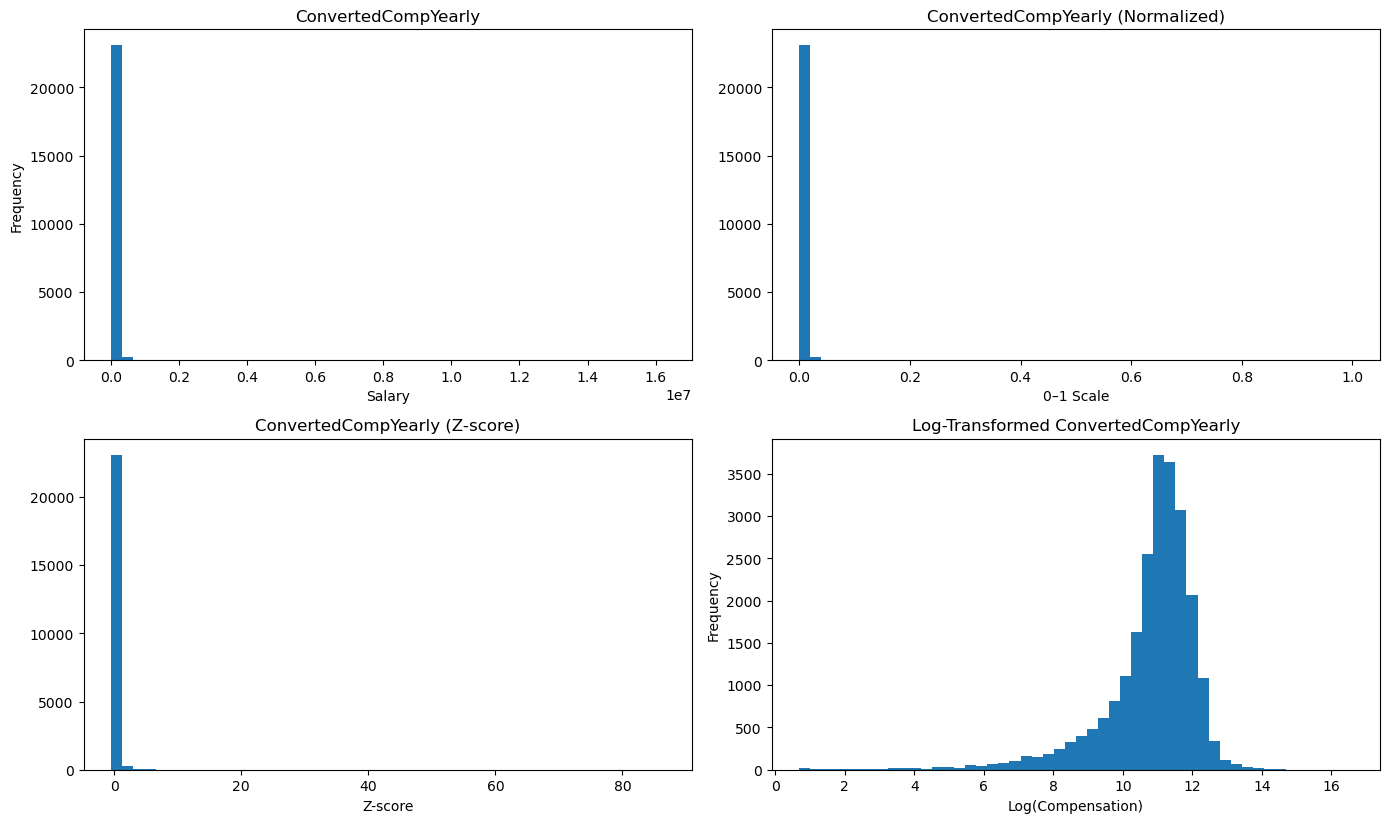

In [36]:
# Visualization of Normalized Data distribution 

plt.figure(figsize=(14, 12))

#  Original Salary
plt.subplot(3, 2, 1)
plt.hist(df_cleaned["ConvertedCompYearly"], bins=50)
plt.title("ConvertedCompYearly")
plt.xlabel("Salary")
plt.ylabel("Frequency")

# Min–Max Normalized
plt.subplot(3,2, 2)
plt.hist(df_cleaned["ConvertedCompYearly_MinMax"], bins=50)
plt.title("ConvertedCompYearly (Normalized)")
plt.xlabel("0–1 Scale")

# Z-score Normalized
plt.subplot(3, 2, 3)
plt.hist(df_cleaned["ConvertedCompYearly_Zscore"], bins=50)
plt.title("ConvertedCompYearly (Z-score)")
plt.xlabel("Z-score")

# Log-transformed distribution
plt.subplot(3, 2, 4)
plt.hist(df_cleaned["ConvertedCompYearly_Log"], bins=50)
plt.title("Log-Transformed ConvertedCompYearly")
plt.xlabel("Log(Compensation)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### Feature Engineering

Create a new column `ExperienceLevel` based on the `YearsCodePro` column:

In [37]:
df_cleaned["YearsCodePro"].unique()

array([nan, '17', '27', '7', '11', '25', '12', '10', '3',
       'Less than 1 year', '18', '37', '15', '20', '6', '2', '16', '8',
       '14', '4', '45', '1', '24', '29', '5', '30', '26', '9', '33', '13',
       '35', '23', '22', '31', '19', '21', '28', '34', '32', '40', '50',
       '39', '44', '42', '41', '36', '38', 'More than 50 years', '43',
       '47', '48', '46', '49'], dtype=object)

In [38]:
df_cleaned.loc[:,"YearsCodePro"] = (
    df_cleaned["YearsCodePro"]
    .replace({
        "Less than 1 year" : 0,
        "More than 50 years" : 50
    })
)

In [39]:
# Convert to numeric, set invalid entries to NaN
df_cleaned.loc[:,"YearsCodePro"] = pd.to_numeric(df_cleaned["YearsCodePro"], errors="coerce")

In [55]:
median_value = df_cleaned["YearsCodePro"].median()

df_cleaned.loc["YearsCodePro"] = df_cleaned["YearsCodePro"].fillna(median_value)

C:\Users\Zakky\AppData\Local\Temp\ipykernel_11728\2435921001.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned["YearsCodePro"] = df_cleaned["YearsCodePro"].fillna(median_value)
C:\Users\Zakky\AppData\Local\Temp\ipykernel_11728\2435921001.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["YearsCodePro"] = df_cleaned["YearsCodePro"].fillna(median_value)


In [48]:
df_cleaned["YearsCodePro"].describe()

count     65437.0
unique       51.0
top           7.0
freq      16344.0
Name: YearsCodePro, dtype: float64

In [49]:
# Now Create a new column ExperienceLevel based on the YearsCodePro column:

bins = [-1, 2, 7, 12, 20, 50]
labels = ["Beginner", "junior", "Mid", "Senior", "Expert"]

df_cleaned.loc[:,"ExperienceLevel"] = pd.cut(df_cleaned["YearsCodePro"], bins=bins, labels=labels)

In [50]:
df_cleaned.to_csv("cleaned_data.csv", index=False)

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation